<a href="https://colab.research.google.com/github/HarshxJiraya/Plant_disease_detection/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import all required libraries for data processing, visualization, and deep learning model development.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt

## Define the directory paths for training and validation datasets.

In [1]:
train = "/content/New Plant Diseases Dataset(Augmented)/train"
valid = "/content/New Plant Diseases Dataset(Augmented)/valid"

## Load the image dataset from the directory structure and prepare batched TensorFlow datasets.

In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train,
    shuffle = True,
    image_size = (224,224),
    batch_size = 32,
    seed = 42
)
valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid,
    shuffle = True,
    image_size = (224,224),
    batch_size = 32
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


#Checking image and label shapes

In [3]:
for image, label in train_ds.take(1):
  print(image.shape)
  print(label.shape)

(32, 224, 224, 3)
(32,)


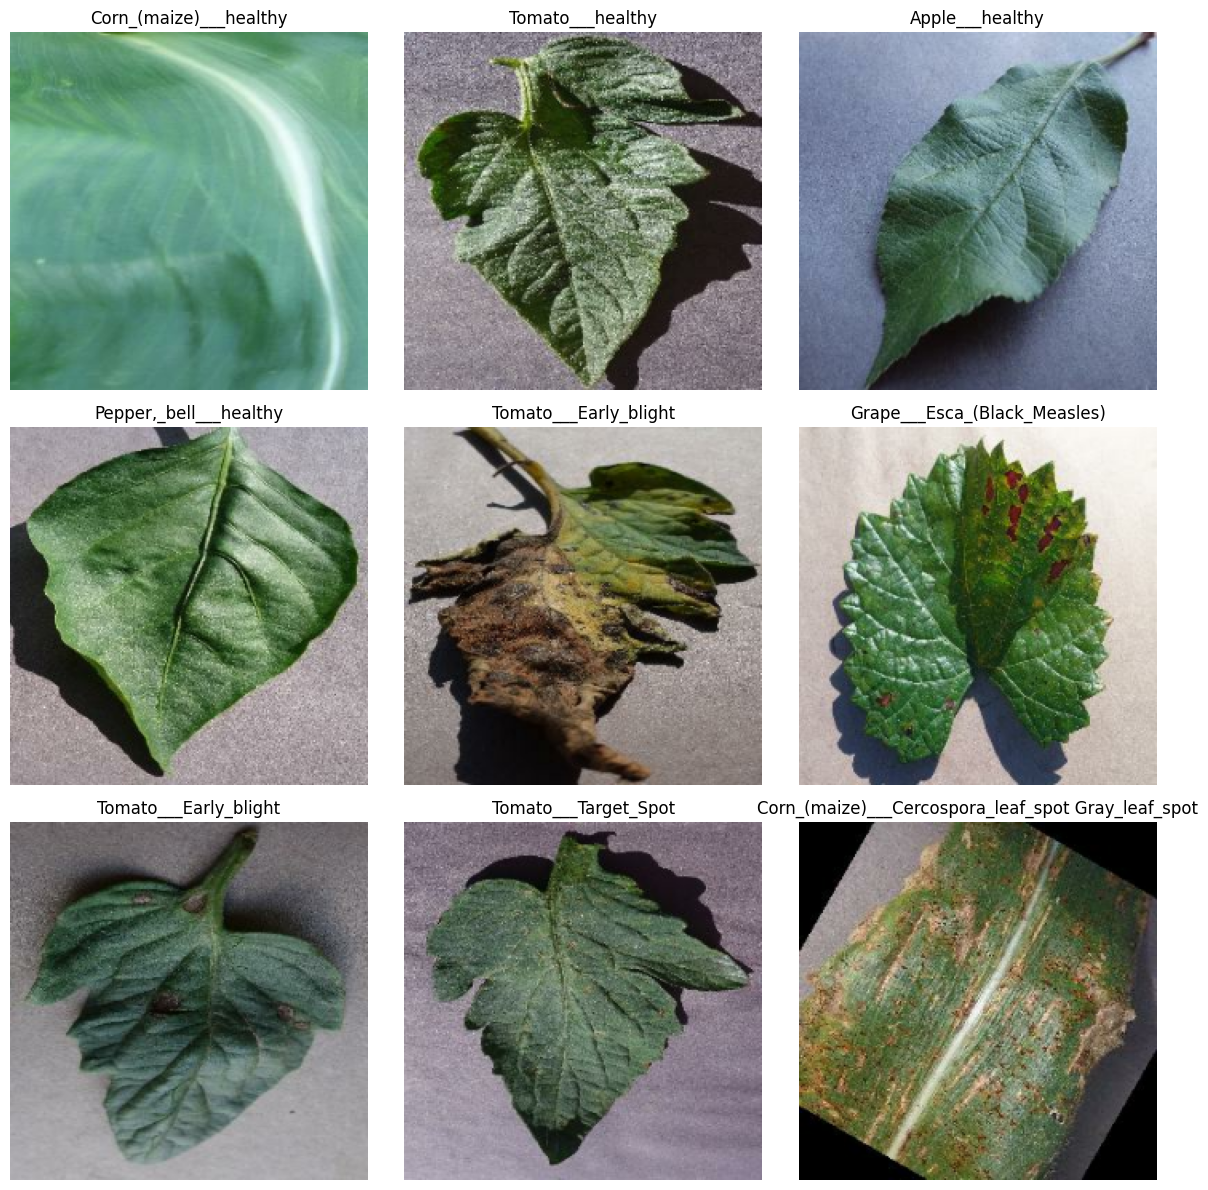

In [5]:
class_names = train_ds.class_names
fig = plt.figure(figsize=(12,12))
for image,labels in train_ds.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(image[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
train_ds = train_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

valid_ds = valid_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [7]:
for image,_ in train_ds.take(1):
  print(image.numpy().min())
  print(image.numpy().max())

0.0
255.0


# Automatically optimize the data pipeline by dynamically managing parallel processing.
AUTOTUNE = tf.data.AUTOTUNE

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
valid_ds = valid_ds.prefetch(tf.data.AUTOTUNE)

## Add custom classification layers on top of the pretrained feature extractor.

In [9]:

base_model = EfficientNetB0(
    include_top=False,
    weights = "imagenet",
    input_shape = (224,224,3)
    )
base_model.trainable = False
model = Sequential()
model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(64,activation = "relu"))
model.add(Dropout(0.2))
model.add(Dense(38,activation="softmax"))

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,224,265 (16.11 MB)

 Trainable params: 174,694 (682.40 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Configure callbacks for early stopping, model checkpointing, and adaptive learning rate scheduling
##Phase 1: Train the custom classification head while keeping the pretrained backbone frozen.

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])
early_stopping = tf.keras.callbacks.EarlyStopping(
    patience = 5,
    restore_best_weights = True,
    mode = "max",
    monitor = "val_accuracy"
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "model.keras",
    monitor = "val_accuracy",
    mode = "max",
    save_best_only = True
)
reducelr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor = "val_loss",
    factor = 0.2,
    patience = 3,
    min_lr = 1e-6
)
callbacks = [
    early_stopping,
    checkpoint,
    reducelr
]
history = model.fit(
    train_ds,
    validation_data = valid_ds,
    epochs = 20,
    callbacks = callbacks
)

# Traning Loss And Validation Loss after Phase 1

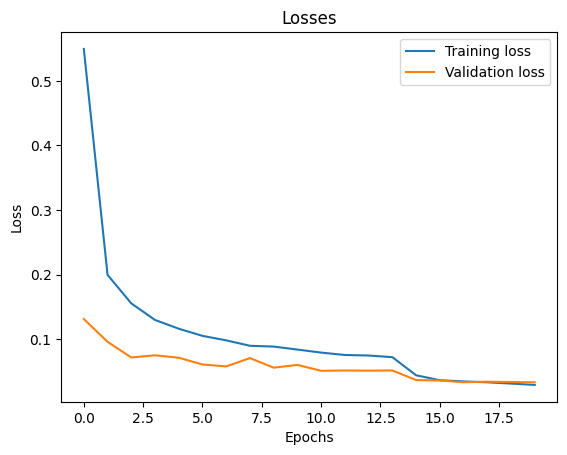

In [15]:
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label = "Validation loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Losses")
plt.show()

In [14]:
loss,accuracy = model.evaluate(valid_ds)


print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.9902 - loss: 0.0338
Loss: 0.0338
Accuracy: 0.9902


## Phase 2: Unfreeze the final layers of the pretrained model and fine-tune them using a lower learning rate.

In [16]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
  layer.trainable = False

## Recompile the model after modifying trainable layers to apply the updated training configuration.

In [19]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])
history2 = model.fit(
    train_ds,
    validation_data = valid_ds,
    epochs = 10,
    callbacks = callbacks
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 189s 73ms/step - accuracy: 0.9761 - loss: 0.0787 - val_accuracy: 0.9909 - val_loss: 0.0292 - learning_rate: 1.0000e-04
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 147s 55ms/step - accuracy: 0.9839 - loss: 0.0531 - val_accuracy: 0.9918 - val_loss: 0.0257 - learning_rate: 1.0000e-04
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 120s 55ms/step - accuracy: 0.9871 - loss: 0.0406 - val_accuracy: 0.9916 - val_loss: 0.0298 - learning_rate: 1.0000e-04
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 162s 64ms/step - accuracy: 0.9896 - loss: 0.0337 - val_accuracy: 0.9937 - val_loss: 0.0212 - learning_rate: 1.0000e-04
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 120s 55ms/step - accuracy: 0.9905 - loss: 0.0302 - val_accuracy: 0.9935 - val_loss: 0.0223 - learning_rate: 1.0000e-04
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 121s 55ms/step - accuracy: 0.9914 - loss: 0.0285 - val_accuracy: 0.9928 - val_loss: 0.0270 - learning_rate: 1.0000e-04
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━

#Traning Loss And Validation Loss after Phase 2

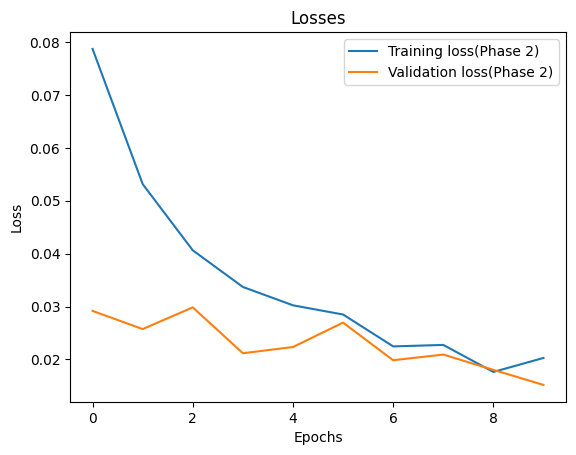

In [21]:
plt.plot(history2.history["loss"],label="Training loss(Phase 2)")
plt.plot(history2.history["val_loss"],label = "Validation loss(Phase 2)")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Losses")
plt.show()

In [22]:
loss,accuracy = model.evaluate(valid_ds)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.9954 - loss: 0.0152
Loss: 0.0152
Accuracy: 0.9954


## Save the trained model for future inference, evaluation, and deployment.

In [23]:
model.save("Plant_Disease_Model.keras")